# 04 — MLP

Standalone notebook. Run `00_Preprocessing.ipynb` first.

In [1]:
import os, time
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from utils import PROCESSED_DIR, RESULTS_DIR, MODELS_DIR, PLOTS_DIR, evaluate, save_results

SEED = 42
tf.random.set_seed(SEED)
MODEL_NAME = "MLP"
DL_EPOCHS = 20
DL_BATCH_SIZE = 256


## Load Preprocessed Data

In [2]:
X_train_res = np.load(os.path.join(PROCESSED_DIR, "X_train_res.npy"))
y_train_res = np.load(os.path.join(PROCESSED_DIR, "y_train_res.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))
class_names = joblib.load(os.path.join(PROCESSED_DIR, "class_names.joblib"))
n_classes = joblib.load(os.path.join(PROCESSED_DIR, "n_classes.joblib"))

print(f"Train: {X_train_res.shape}, Test: {X_test.shape}, classes: {n_classes}")


Train: (911664, 78), Test: (53582, 78), classes: 15


## Build & Train

In [3]:
def build_mlp(input_dim, n_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


model = build_mlp(X_train_res.shape[1], n_classes)
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

t0 = time.time()
history = model.fit(
    X_train_res, y_train_res, validation_split=0.1,
    epochs=DL_EPOCHS, batch_size=DL_BATCH_SIZE,
    callbacks=[early_stop], verbose=2,
)
train_time = time.time() - t0
print(f"Train time: {train_time:.2f}s")


Epoch 1/20
3206/3206 - 10s - 3ms/step - accuracy: 0.9164 - loss: 0.2657 - val_accuracy: 0.4075 - val_loss: 5.4560
Epoch 2/20
3206/3206 - 8s - 3ms/step - accuracy: 0.9667 - loss: 0.1028 - val_accuracy: 0.4175 - val_loss: 4.6802
Epoch 3/20
3206/3206 - 8s - 2ms/step - accuracy: 0.9724 - loss: 0.0848 - val_accuracy: 0.4187 - val_loss: 4.6280
Epoch 4/20
3206/3206 - 8s - 2ms/step - accuracy: 0.9750 - loss: 0.0761 - val_accuracy: 0.4096 - val_loss: 4.2716
Epoch 5/20
3206/3206 - 8s - 2ms/step - accuracy: 0.9765 - loss: 0.0723 - val_accuracy: 0.4157 - val_loss: 4.2889
Epoch 6/20
3206/3206 - 9s - 3ms/step - accuracy: 0.9774 - loss: 0.0690 - val_accuracy: 0.4181 - val_loss: 4.4475
Epoch 7/20
3206/3206 - 8s - 2ms/step - accuracy: 0.9781 - loss: 0.0666 - val_accuracy: 0.4167 - val_loss: 4.2593
Epoch 8/20
3206/3206 - 8s - 2ms/step - accuracy: 0.9788 - loss: 0.0640 - val_accuracy: 0.4136 - val_loss: 4.2091
Epoch 9/20
3206/3206 - 8s - 3ms/step - accuracy: 0.9792 - loss: 0.0633 - val_accuracy: 0.4194 -

## Predict & Evaluate

In [4]:
t0 = time.time()
y_proba = model.predict(X_test, verbose=0)
infer_time = time.time() - t0
y_pred = np.argmax(y_proba, axis=1)

row = evaluate(MODEL_NAME, y_test, y_pred, y_proba, train_time, infer_time, n_classes)
for k, v in row.items():
    if k not in ("Confusion Matrix",):
        print(f"{k}: {v}")


Model: MLP
Accuracy: 0.9608637228920159
Precision: 0.5768307269057535
Recall: 0.8405892537196721
F1-Score: 0.638185792623408
ROC-AUC: nan
MCC: 0.8929438901965021
Cohen's Kappa: 0.8880570368198984
Train Time (s): 111.15002775192261
Prediction Time (s): 2.0769991874694824


## Training Curves

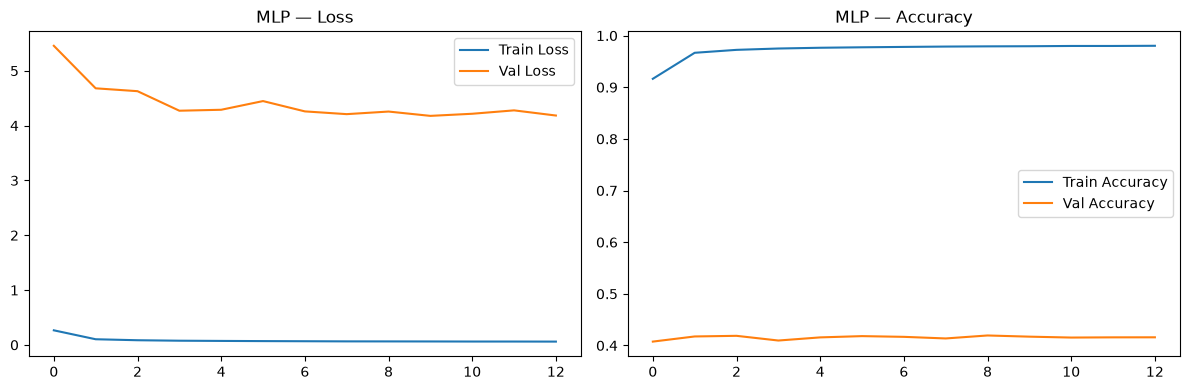

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title(f"{MODEL_NAME} — Loss"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title(f"{MODEL_NAME} — Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "MLP_training_curves.png"), dpi=150)
plt.show()


## Confusion Matrix Plot

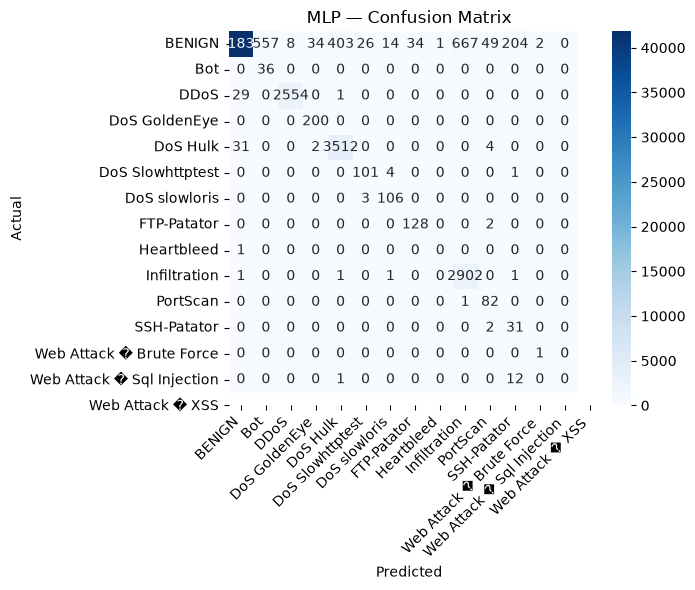

In [6]:
cm = np.array(row["Confusion Matrix"])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{MODEL_NAME} — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "MLP_confusion_matrix.png"), dpi=150)
plt.show()


## Save Results & Model

In [7]:
save_results(MODEL_NAME, row, history=history.history)
model.save(os.path.join(MODELS_DIR, "MLP.keras"))
print("Saved model and results for", MODEL_NAME)


Saved results to results\MLP_results.json
Saved model and results for MLP
